In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from onnxruntime.tools.ort_format_model.types import value_name_to_typestr

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, VotingClassifier, RandomForestClassifier, GradientBoostingRegressor, HistGradientBoostingRegressor, StackingClassifier
from sklearn.datasets import make_moons, fetch_openml, fetch_california_housing, fetch_openml
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sympy.stats.rv import probability

# Ensemble Learning

## Hard & Soft Voting

To implement hard voting classifier, SKLearn provides VotingClassifier class

In [2]:
X, y = make_moons(500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression()),
        ("svc", SVC()),
        ("rf", RandomForestClassifier()),
    ]
)
voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('svc', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


Let's see estimators performance one by one

In [3]:
# Using named_estimators_ to get fitted versions, instead of copies
for name, clf in voting_clf.named_estimators_.items():
    print(f"{name} - {clf.score(X_test, y_test)}")

lr - 0.864
svc - 0.896
rf - 0.896


Top result is - 0.896. Now, we can make and ensemble prediction:

In [4]:
voting_clf.predict(X_test[:1])

array([1])

In [5]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([0]), array([1])]

In [6]:
voting_clf.score(X_test, y_test)

0.904

Score is higher than the best ensemble predictor!

To perform soft voting, which generally leads to better results. All the models must have predict_proba method. Since we're using SVM, we need to set probability parameter to True.

In [7]:
voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.928

## Bagging and Pasting

This code plots one decision tree and ensemble of 500 bagging trees. Bagging is an ensemble approach, that allows reusing training instances for each model, which leads to more independent ensemble models. Basically, we're making Bias high to reduce overall Variance.

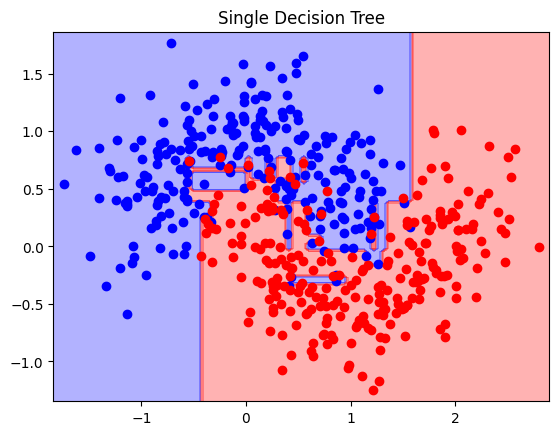

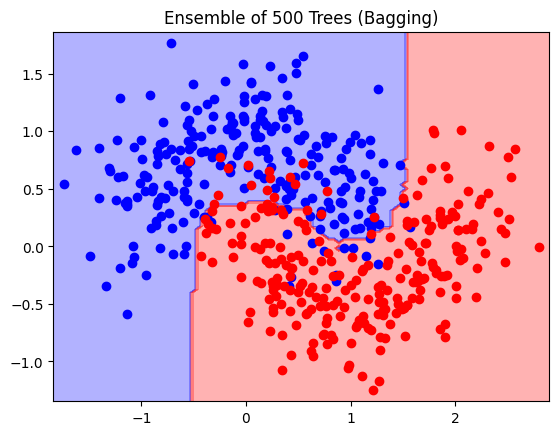

In [8]:
def plot_decision_tree(clf, X, y, title: str, axes = [-1, 1, -1, 1], plot_training: bool = True, configure_axes: bool = True) -> None:
    """Plots only two classes classification"""
    if configure_axes:
        axes[0], axes[1], axes[2], axes[3] = np.min(X[:, 0]) - 0.1, np.max(X[:, 0]) + 0.1, np.max(X[:, 1]) + 0.1, np.min(X[:, 1]) - 0.1

    X1s = np.linspace(axes[0], axes[1], 100)
    X2s = np.linspace(axes[2], axes[3], 100)

    x1, x2 = np.meshgrid(X1s, X2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=ListedColormap(["blue", "red"]))

    if plot_training:
        plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c="blue")
        plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c="red")

    plt.title(title)
    plt.show()

X_train, y_train = make_moons(500, noise=0.3, random_state=42)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)

plot_decision_tree(tree_clf, X_train, y_train, title="Single Decision Tree")
plot_decision_tree(bag_clf, X_train, y_train, title="Ensemble of 500 Trees (Bagging)")

As we can see, bagging ensemble model is more likely to generalize well.

## Out-of-Bag evaluation (OOB)

Using bagging approach, each model is being feed with $64\%$ instances on average. These $35\%$ called Out-of-Bag instances.

Is there is enough models, each training instance would be an OOB instance for a couple of models. We can use these instances, to evaluate model performance.

In [9]:
X, y = make_moons(500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

In [10]:
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

As we can see, OOB evaluation is a bit pessimistic

In [11]:
bag_clf.oob_decision_function_[:3]

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

## Random Forests

Basically random forests is and ensemble of decision trees, SKLearn provides RandomForestClassifier and RandomForestRegressor classes. Also, it provides some unusual models, like extra random trees _(which use random features on each tree split)_.

### Feature importance's

Since, decision trees in random forests are tending to lower split impurity, we can compute average impurity lowering for each feature. Then scale them, so they would sum up to 1.

In [12]:
X, y = fetch_openml('mnist_784', as_frame=False, return_X_y=True)
mnist_fores_clf = RandomForestClassifier(n_estimators=500, random_state=42, verbose=1, n_jobs=-1)
mnist_fores_clf.fit(X, y)

feature_importance = mnist_fores_clf.feature_importances_

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   14.2s finished


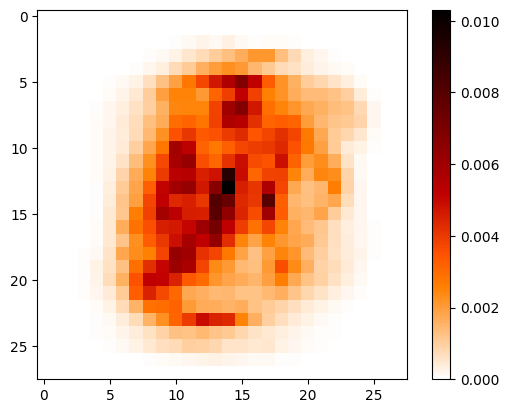

In [13]:
plt.imshow(feature_importance.reshape(28, 28), cmap="gist_heat_r")
plt.colorbar()
plt.show()

## AdaBoost

AdaBoost is and ensemble method, that uses prediction errors to train new ensemble models. It adds more weight to misclassified instances during training. SKLearn uses AdaBoost classes called AdaBoostClassifier _(which can perform multiclass classification out of bag)_ and AdaBoostRegressor.


## Gradient Boosting

Gradient boosting trains models sequentially on previous models erros.

Manual implementation

In [14]:
X = np.random.rand(100, 1)
y = 3 * X ** 2 + np.random.rand(100, 1)

tree_reg = DecisionTreeRegressor(max_depth=2)
tree_reg.fit(X, y)
pass

In [15]:
y2 = y - tree_reg.predict(X)[:, np.newaxis]

tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X, y2)
pass

In [16]:
y3 = y2 - tree_reg2.predict(X)[:, np.newaxis]
tree_reg3 = DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(X, y3)
pass

In [17]:
X_new = np.array([[-0.3], [0.0], [0.7]])
sum(tree.predict(X_new) for tree in (tree_reg, tree_reg2, tree_reg3))

array([0.56026638, 0.56026638, 1.82244823])

Using SKLearn

In [18]:
grbt_reg = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0)
grbt_reg.fit(X, y.ravel())
grbt_reg.predict(X_new)

array([0.56026638, 0.56026638, 1.82244823])

Same Results!

### Histogram Based Gradient Boosting

This method converts all numeric attributes to a specific range of bins _(can't be set higher than 255)_, it leads to more efficient computational complexity. To be concise: $O(b \times m)$, where $b$ represents amount of bins

Let's see how to this using California housing dataset

In [19]:
HOUSING_PATH = os.path.join('datasets', 'housing')

def extract_housing_data(housing_path: str = HOUSING_PATH) -> pd.DataFrame:
    # join base path with exact filename
    csv_housing_path = os.path.join(housing_path, 'housing.csv')

    # return pandas DataFrame
    return pd.read_csv(csv_housing_path)

housing = extract_housing_data()

X = housing.drop(["median_house_value"], axis=1)
y = housing["median_house_value"]


This code is taken from 1-Housing.ipynb.

Create pipline to transform categorial feature and make prediction using HGBR

In [20]:
hbgb_pipeline = make_pipeline(
    make_column_transformer((OrdinalEncoder(), ["ocean_proximity"]), remainder="passthrough"), # passthrough remainders to keep all unspecified columns
    HistGradientBoostingRegressor()
)

Cross validation...

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2)

score = cross_val_score(hbgb_pipeline, X_train, y_train, cv=5, scoring="neg_mean_squared_error")
print(f"RMSE: {np.sqrt(-score.mean()):.2f}")

RMSE: 48463.00


As we can see, results are pretty good!

## Stacking

# Exercises

1. If you have trained five different models on the exact same training data, and they all achieve 95% precision, is there any chance that you can combine these models to get better results? If so, how? If not, why?

> Yes, we would achieve better results. Only, if models are independent enough and making different mistakes. This can be proved using _law of large numbers_.

2. What is the difference between hard and soft voting classifiers?

> Hard voting takes final predictions, on the other hand, soft voting chooses between `prediction_proba` outputs. Usually, soft voting performs better, because it gives more weight to confident predictions.

3. Is it possible to speed up training of a bagging ensemble by distributing it across multiple servers? What about pasting ensembles, boosting ensembles, random forests, or stacking ensembles?

> Yes, it is possible to train bagging or pasting ensemble model using multiple threads, because bagging trains models independently. Random forests also can be trained in multiple threads. But, we can't use this approach with boosting  and some stacking cases _(more than one layered stack)_, because each model depends on predictions of its predecessor.

4. What is the benefit of out-of-bag evaluation?

> OOB is very efficient, because it takes fewer predictions to make to compute ensemble accuracy and allows to validate model without splitting dataset into training and validating part. Provided if there is enough amount of models in the ensemble and bootstrapping is on

5. What makes extra-trees ensembles more random than regular random forests? How can this extra randomness help? Are extra-trees classifiers slower or faster than regular random forests?

> Extra-trees are using random subsets of feature at each splitting node _(also true for forests)_ and random thresholds. This extra randomness can help increase individual model's Bias, which will lead to lower ensemble Variance. Extra-trees are much faster that regular forests.

6. If your AdaBoost ensemble underfits the training data, which hyperparameters should you tweak, and how?

> You should increase $\eta$ learning rate hyperparameter. It will manage each predictor weights. Or: increase number of estimators, less regularize base estimator.

7. If your gradient boosting ensemble overfits the training set, should you increase or decrease the learning rate?

> You should decrease learning rate to increase number of estimators and decrease their contributing to final prediction _(if trees are overfitting the training set)_.

8. Load the MNIST dataset (introduced in Chapter 3), and split it into a training set, a validation set, and a test set (e.g., use 50,000 instances for training, 10,000 for validation, and 10,000 for testing). Then train various classifiers, such as a random forest classifier, an extra-trees classifier, and an SVM classifier. Next, try to combine them into an ensemble that outperforms each individual classifier on the validation set, using soft or hard voting. Once you have found one, try it on the test set. How much better does it perform compared to the individual classifiers?


In [22]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

In [23]:
mnist

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',


In [24]:
mnist_X, mnist_y = mnist.data, mnist.target

scaler = StandardScaler()

X_train, y_train = mnist_X[:40000], mnist_y[:40000]
X_valid, y_valid = mnist_X[40000:50000], mnist_y[40000:50000]
X_test, y_test = mnist_X[60000:70001], mnist_y[60000:70001]

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

In [25]:
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier

svm_clf_1 = SVC(probability=True, kernel="rbf")
svm_clf_1.fit(X_train[:10000], y_train[:10000].ravel())

svm_clf_2 = SVC(probability=True, kernel="poly")
svm_clf_2.fit(X_train[10000:20000], y_train[10000:20000].ravel())

svm_clf_3 = SVC(probability=True, kernel="linear")
svm_clf_3.fit(X_train[20000:30000], y_train[20000:30000].ravel())

print("Finished SVCs training")

log_reg_clf = LogisticRegression(max_iter=500)
log_reg_clf.fit(X_train, y_train.ravel())

print("Finished Logistic Regressions training")

forest_clf = RandomForestClassifier(n_estimators=300, n_jobs=-1)
forest_clf.fit(X_train[20000:40000], y_train[20000:40000].ravel())

print("Finished Random Forest Classifier training")


extra_trees_clf = ExtraTreesClassifier()
extra_trees_clf.fit(X_train[:20000], y_train[:20000].ravel())
print("Finished ExtraTrees Classifier")

Finished SVCs training
Finished Logistic Regressions training
Finished Random Forest Classifier training
Finished ExtraTrees Classifier


In [46]:
ensemble = [svm_clf_1, svm_clf_2, svm_clf_3, log_reg_clf]

def make_ensemble_predictions(X, Y, soft: bool, ensemble: list = ensemble, log_individual=False):
    if log_individual:
        predictions = predictions = [np.array(clf.predict(X)) for clf in ensemble]
        print("Individual accuracy:")
        for clf_predictions, clf in zip(predictions, ensemble):
            print(f"Accuracy for {clf}: {accuracy_score(Y.ravel(), clf_predictions)}")

    if soft:
        probas = [clf.predict_proba(X) for clf in ensemble]
        summed_probas = np.zeros(probas[0].shape)

        for clf_probas in probas:
            summed_probas += clf_probas

        summed_probas /= len(ensemble)

        final_predictions = summed_probas.argmax(axis=1, keepdims=True)

        print(f"Soft voting ensemble predictions accuracy: {accuracy_score(Y.ravel().astype(int), final_predictions.ravel().astype(int))}")
    else:
        predictions = np.c_[*[clf.predict(X).astype(int)[:, np.newaxis] for clf in ensemble]]
        final_predictions = np.apply_along_axis(lambda row: np.bincount(row).argmax(axis=0), axis=1, arr=predictions)

        print(f"Hard voting ensemble predictions accuracy: {accuracy_score(Y.ravel().astype(int), final_predictions.ravel().astype(int))}")

make_ensemble_predictions(X_valid, y_valid, True, ensemble, log_individual=True)
make_ensemble_predictions(X_valid, y_valid, False, ensemble)

Individual accuracy:
Accuracy for SVC(probability=True): 0.929
Accuracy for SVC(kernel='poly', probability=True): 0.8793
Accuracy for SVC(kernel='linear', probability=True): 0.9029
Accuracy for LogisticRegression(max_iter=500): 0.9008
Soft voting ensemble predictions accuracy: 0.9405
Hard voting ensemble predictions accuracy: 0.9322


9. Run the individual classifiers from the previous exercise to make predictions on the validation set, and create a new training set with the resulting predictions: each training instance is a vector containing the set of predictions from all your classifiers for an image, and the target is the image's class. Train a classifier on this new training set. Congratulations—you have just trained a blender, and together with the classifiers it forms a stacking ensemble! Now evaluate the ensemble on the test set. For each image in the test set, make predictions with all your classifiers, then feed the predictions to the blender to get the ensemble's predictions. How does it compare to the voting classifier you trained earlier? Now try again using a StackingClassifier instead. Do you get better performance? If so, why?

In [54]:
def get_ensemble_probas(ensemble: list, X):
    """All ensemble models must support predict_proba"""
    probas = [clf.predict_proba(X) for clf in ensemble]

    return np.c_[*probas]

ensemble_valid_blending_data = get_ensemble_probas(ensemble, X_valid)

In [58]:
blender = LogisticRegression(max_iter=1000)
blender.fit(ensemble_valid_blending_data, y_valid)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [59]:
def stacking_ensemble_prediction(X, y, ensemble, blender: LogisticRegression):
    predictions = get_ensemble_probas(ensemble, X)
    print(predictions[1])
    print(predictions.shape)
    final_predictions = blender.predict(predictions)

    print(f"Stacking ensemble predictions accuracy: {accuracy_score(y.ravel(), final_predictions.ravel())}")

stacking_ensemble_prediction(X_test, y_test, ensemble, blender)

[7.56978986e-003 4.29430472e-003 2.48097799e-001 1.72088768e-001
 2.03975068e-002 5.17431743e-002 1.24386604e-001 2.90332665e-001
 2.29732891e-002 5.81160991e-002 8.67995501e-014 1.53000582e-014
 9.99999834e-001 3.33333611e-008 1.25000104e-008 2.00000167e-008
 5.00000417e-008 1.11111204e-008 2.50000208e-008 1.42857262e-008
 2.24776337e-014 1.81794415e-014 9.99999775e-001 1.00000077e-007
 1.11111197e-008 2.00000155e-008 3.33333592e-008 1.25000097e-008
 3.33333592e-008 1.42857254e-008 3.30540155e-169 0.00000000e+000
 1.06699578e-022 1.24861905e-293 0.00000000e+000 2.40743367e-318
 1.00000000e+000 0.00000000e+000 3.56491702e-130 0.00000000e+000]
(10000, 40)
Stacking ensemble predictions accuracy: 0.8371


In [30]:
stacking_clf = StackingClassifier([(f"{i}: {clf.__class__.__name__}", clf) for i, clf in enumerate(ensemble)], LogisticRegression(max_iter=1000), cv=5, verbose=0)
stacking_clf.fit(X_train[:10000], y_train[:10000])
print(f"SKLearn stacking classifier accuracy: {accuracy_score(y_valid.ravel(), stacking_clf.predict(X_valid).ravel())}")

SKLearn stacking classifier accuracy: 0.9436


My implementation of stacking classfier is losing to SKLearn's, because uses some advanced techniques, like separating training set in to folds.

But, stacking approach increased ourl accuracy roughly by $0.35\%$!